# Ablation C - HFE No Gate

Input -> USFM -> HFE(no gate) -> Extra Attention Block -> CLS -> Head -> Output

In [1]:
import torch, subprocess

print(f'cuda available: {torch.cuda.is_available()}')
print(f'visible gpus: {torch.cuda.device_count()}')
print(f'dataparallel suggested: {torch.cuda.device_count() > 1}')
if torch.cuda.is_available():
    print('gpu names:', [torch.cuda.get_device_name(i) for i in range(torch.cuda.device_count())])
try:
    q = ['nvidia-smi','--query-gpu=index,memory.used,memory.total,utilization.gpu','--format=csv,noheader,nounits']
    out = subprocess.check_output(q, text=True).strip()
    print('per-gpu (idx, mem_usedMB, mem_totalMB, util%):')
    print(out if out else '(empty)')
except Exception as e:
    print(f'nvidia-smi unavailable: {e}')


cuda available: True
visible gpus: 2
dataparallel suggested: True
gpu names: ['NVIDIA RTX A5000', 'NVIDIA RTX A5000']
per-gpu (idx, mem_usedMB, mem_totalMB, util%):
0, 11203, 24564, 0
1, 9413, 24564, 0


In [2]:
import os
import sys
import copy
from pathlib import Path
import numpy as np
import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import Dataset, DataLoader
from torch.optim import AdamW
from torch.optim.lr_scheduler import CosineAnnealingLR
import torchvision.transforms as transforms
from PIL import Image
import matplotlib.pyplot as plt
from tqdm import tqdm
import json
import timm
from timm.layers import DropPath

BASE_PATH = Path('/gpfs/gibbs/project/papademetris/jg3279')
DATA_PATH = BASE_PATH / 'data' / 'USenhance_2023_split'
OUTPUT_PATH = BASE_PATH / 'USFM' / 'week9' / 'ablation_C_hfe_nogate'
OUTPUT_PATH.mkdir(parents=True, exist_ok=True)

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f'Device: {device}')

CONFIG = {
    'batch_size': 64,
    'num_epochs': 50,
    'learning_rate': 3e-4,
    'last3_lr_multiplier': 0.2,
    'hfe_lr_multiplier': 1.0,
    'extra_block_lr_multiplier': 0.3,
    'head_lr_multiplier': 1.0,
    'weight_decay': 1e-4,
    'num_workers': 8,
    'organ_classes': ['breast', 'carotid', 'kidney', 'liver', 'thyroid']
}

Device: cuda


In [3]:
class FeatureLevelHFE(nn.Module):
    """Feature-level High-Frequency Enhancer"""
    def __init__(self, feature_dim, num_scales=3):
        super().__init__()
        self.feature_dim = feature_dim
        self.num_scales = num_scales
        
        # Multi-scale feature extraction
        self.scale_extractors = nn.ModuleList([
            nn.Conv1d(feature_dim, feature_dim, kernel_size=3, padding=1),
            nn.Conv1d(feature_dim, feature_dim, kernel_size=5, padding=2),
            nn.Conv1d(feature_dim, feature_dim, kernel_size=7, padding=3),
        ])
        
        # Fusion weights
        self.fusion_weights = nn.Parameter(torch.ones(num_scales) / num_scales)
        
        # ablation C: remove tanh gate and learn direct enhancement scale
        self.strength_scale = nn.Parameter(torch.tensor(0.1))  # ablation C: no gate
        
        # Refinement mask (MLP)
        self.refiner = nn.Sequential(
            nn.Linear(feature_dim, feature_dim // 2),
            nn.GELU(),
            nn.Linear(feature_dim // 2, feature_dim),
        )
        # bias 初始化为负值，让 sigmoid 初始更保守（接近 0.12），避免早期增强太激进
        nn.init.constant_(self.refiner[-1].bias, -2.0)
    
    def forward(self, x):
        """
        Args:
            x: [B, N, D] token features from ViT (N=197: 1 cls + 196 patch tokens)
        Returns:
            enhanced_x: [B, N, D]
        """
        B, N, D = x.shape
        
        # ── 分离 CLS token 和 patch tokens ──────────────────────────
        cls_token    = x[:, :1, :]   # [B, 1, D]
        patch_tokens = x[:, 1:, :]   # [B, N-1, D]
        
        # Transpose for Conv1d: [B, N-1, D] -> [B, D, N-1]
        x_conv = patch_tokens.transpose(1, 2)
        
        # Multi-scale feature extraction
        hf_features = []
        for extractor in self.scale_extractors:
            hf  = extractor(x_conv)
            std = hf.std(dim=2, keepdim=True).clamp_min(1e-3)
            hf  = (hf - hf.mean(dim=2, keepdim=True)) / std
            hf_features.append(hf)
        
        # Transpose back: [B, D, N-1] -> [B, N-1, D]
        hf_features = [hf.transpose(1, 2) for hf in hf_features]
        
        # Fusion
        weights  = F.softmax(self.fusion_weights, dim=0)
        fused_hf = torch.stack(hf_features, dim=0)
        fused_hf = (fused_hf * weights.view(-1, 1, 1, 1)).sum(dim=0)
        
        # Adaptive mask: sigmoid with temperature
        mask = torch.sigmoid(self.refiner(fused_hf) / 2.0)  # [B, N-1, D]
        
        # ablation C: no tanh gate, direct learned scale
        enhanced_patches = patch_tokens + self.strength_scale * fused_hf * mask
        
        # ── 拼回 CLS token (pass-through) ───────────────────────────
        enhanced_x = torch.cat([cls_token, enhanced_patches], dim=1)  # [B, N, D]
        
        return enhanced_x

print('✓ FeatureLevelHFE defined')

✓ FeatureLevelHFE defined


In [4]:
class OrganDataset(Dataset):
    def __init__(self, data_path, split='train', transform=None):
        self.split = split
        self.transform = transform
        self.organ_classes = CONFIG['organ_classes']
        self.organ_to_idx = {organ: idx for idx, organ in enumerate(self.organ_classes)}
        self.data_path = Path(data_path) / split
        self.samples = []
        self._load_samples()
    
    def _load_samples(self):
        for organ in self.organ_classes:
            organ_path = self.data_path / organ
            if organ_path.exists():
                for quality_dir in organ_path.glob('*quality'):
                    for img_file in quality_dir.glob('*.png'):
                        self.samples.append({
                            'path': img_file,
                            'organ': organ,
                            'organ_idx': self.organ_to_idx[organ],
                            'quality': quality_dir.name
                        })
        print(f'✓ {self.split.upper()}: {len(self.samples)} images')
    
    def __len__(self):
        return len(self.samples)
    
    def __getitem__(self, idx):
        sample = self.samples[idx]
        img = Image.open(sample['path']).convert('RGB')
        if self.transform:
            img = self.transform(img)
        return {
            'image': img,
            'organ_label': sample['organ_idx'],
            'organ_name': sample['organ'],
            'quality': sample['quality']
        }

print('✓ Dataset defined')

✓ Dataset defined


In [5]:
def _reset_vit_block(block: nn.Module) -> None:
    """
    Properly re-initialize a timm ViT block.
    timm 的 Block/Attention/Mlp 大多没有 reset_parameters()，
    手动遍历所有 Linear 和 LayerNorm，用 ViT 标准初始化。
    """
    for m in block.modules():
        if isinstance(m, nn.Linear):
            nn.init.trunc_normal_(m.weight, std=0.02)
            if m.bias is not None:
                nn.init.zeros_(m.bias)
        elif isinstance(m, nn.LayerNorm):
            nn.init.ones_(m.weight)
            nn.init.zeros_(m.bias)


class OrganClassifierWithFeatureHFE(nn.Module):
    """
    USFM → HFE(patch tokens) → Extra Transformer Block → CLS → Head
    """
    def __init__(self, backbone, num_classes=5):
        super().__init__()
        self.backbone = backbone
        self.num_classes = num_classes
        
        with torch.no_grad():
            dummy_input = torch.randn(1, 3, 224, 224).to(next(backbone.parameters()).device)
            features    = backbone.forward_features(dummy_input)
            feature_dim = features.shape[-1]
            num_tokens  = features.shape[1]
        
        self.feature_dim = feature_dim
        print(f'✓ Feature shape: {num_tokens} tokens × {feature_dim} dim')
        
        # Feature-level HFE
        self.hfe = FeatureLevelHFE(feature_dim=feature_dim, num_scales=3)
        print(f'✓ Feature-level HFE initialized')
        
        # Extra Transformer block:
        # deepcopy backbone 最后一层 → Pre-LN/GELU/qkv bias 与 USFM 完全一致
        # ViT 标准初始化重置权重，drop_path 关掉
        self.extra_block = copy.deepcopy(backbone.blocks[-1])
        _reset_vit_block(self.extra_block)
        for m in self.extra_block.modules():
            if isinstance(m, DropPath):
                m.drop_prob = 0.0
        print(f'✓ Extra Transformer block initialized (deepcopy + ViT re-init + drop_path=0)')
        self.final_norm = nn.LayerNorm(feature_dim)
        
        # Classification head (GELU 与 backbone 风格一致)
        self.classifier = nn.Sequential(
            nn.Linear(feature_dim, 512),
            nn.GELU(),
            nn.Dropout(0.3),
            nn.Linear(512, num_classes)
        )
        
        self._freeze_all_but_last_3_layers()
    
    def _freeze_all_but_last_3_layers(self):
        for param in self.backbone.parameters():
            param.requires_grad = False
        if hasattr(self.backbone, 'blocks'):
            for block in self.backbone.blocks[-3:]:
                for param in block.parameters():
                    param.requires_grad = True
        if hasattr(self.backbone, 'norm'):
            for param in self.backbone.norm.parameters():
                param.requires_grad = True
        print('✓ Backbone: last 3 blocks unfrozen')
    
    def forward(self, x):
        features          = self.backbone.forward_features(x)    # [B, 197, 768]
        enhanced_features = self.hfe(features)                   # [B, 197, 768]
        refined_features  = self.extra_block(enhanced_features)  # [B, 197, 768]
        cls_token         = refined_features[:, 0, :]            # [B, 768]
        cls_token         = self.final_norm(cls_token)
        return self.classifier(cls_token)
    
    def extract_features(self, x):
        features          = self.backbone.forward_features(x)
        enhanced_features = self.hfe(features)
        refined_features  = self.extra_block(enhanced_features)
        return self.final_norm(refined_features[:, 0, :])
    
    def get_param_groups(self, base_lr=3e-4):
        param_groups = [
            {
                'params': list(self.hfe.parameters()),
                'lr': base_lr * CONFIG['hfe_lr_multiplier'],
                'name': 'HFE'
            },
            {
                'params': list(self.extra_block.parameters()),
                'lr': base_lr * CONFIG['extra_block_lr_multiplier'],
                'name': 'ExtraBlock'
            },
            {
                'params': list(self.final_norm.parameters()) + list(self.classifier.parameters()),
                'lr': base_lr * CONFIG['head_lr_multiplier'],
                'name': 'Head'
            },
        ]
        
        last3_params = []
        if hasattr(self.backbone, 'blocks'):
            for block in self.backbone.blocks[-3:]:
                last3_params.extend(list(block.parameters()))
        if hasattr(self.backbone, 'norm'):
            last3_params.extend(list(self.backbone.norm.parameters()))
        param_groups.append({
            'params': last3_params,
            'lr': base_lr * CONFIG['last3_lr_multiplier'],
            'name': 'Last3Layers'
        })
        
        # 重复参数检查
        all_params = [p for g in param_groups for p in g['params']]
        assert len(set(map(id, all_params))) == len(all_params), \
            '❌ Duplicate parameters detected in optimizer groups!'
        
        return param_groups

print('✓ Model class defined')

✓ Model class defined


In [6]:
# ─────────────────────────────────────────────────────────────────
# FFT Visualization
# 目的：证明 HFE 提高了 patch token 序列的高频能量占比
# FFT 沿 token 序列维度 (N=196) 做，作为 patch-token 空间频率的 proxy
# ─────────────────────────────────────────────────────────────────

HF_THRESHOLD = 0.25  # rfftfreq(196) 范围是 [0, 0.5]，取上四分位

def compute_feature_fft(token_features: torch.Tensor) -> tuple:
    """
    FFT along the patch-token sequence dimension (N=196),
    used as a proxy for high-frequency spatial variation in token embeddings.

    Args:
        token_features: [B, N-1, D]  (patch tokens only, CLS excluded)
    Returns:
        freqs:     [N//2+1], range [0, 0.5]
        magnitude: [N//2+1], averaged over batch and feature dim
    """
    fft_result = torch.fft.rfft(token_features.float(), dim=1)  # [B, N//2+1, D]
    magnitude   = fft_result.abs().mean(dim=(0, 2)).cpu().numpy()  # [N//2+1]
    freqs       = np.fft.rfftfreq(token_features.shape[1])         # [N//2+1]
    return freqs, magnitude


def visualize_hfe_fft(model, dataloader, device, num_batches=5,
                      save_path=None, title_suffix=''):
    """
    Two-panel plot: Without HFE (raw patch tokens) vs With HFE.
    HF ratio computed with correct threshold (freqs >= HF_THRESHOLD).

    alpha gate が 0 に初期化されているため:
      - 訓練前: Δ ≈ 0  (identity に近い)
      - 訓練後: Δ > 0  (学習された高周波強調)
    """
    model.eval()
    actual_model = model.module if isinstance(model, nn.DataParallel) else model
    backbone_model = actual_model.backbone

    before_mags, after_mags = [], []

    with torch.no_grad():
        for i, batch in enumerate(dataloader):
            if i >= num_batches:
                break
            images = batch['image'].to(device)

            # Without HFE: raw patch tokens
            features     = backbone_model.forward_features(images)  # [B, 197, 768]
            patch_before = features[:, 1:, :]                       # [B, 196, 768]

            # With HFE
            enhanced    = actual_model.hfe(features)                # [B, 197, 768]
            patch_after = enhanced[:, 1:, :]                        # [B, 196, 768]

            freqs, mag_before = compute_feature_fft(patch_before)
            _,     mag_after  = compute_feature_fft(patch_after)

            before_mags.append(mag_before)
            after_mags.append(mag_after)

    mag_before = np.mean(before_mags, axis=0)
    mag_after  = np.mean(after_mags,  axis=0)

    # ── Plot ─────────────────────────────────────────────────────
    fig, axes = plt.subplots(1, 2, figsize=(14, 5))
    fig.suptitle(
        f'Token-sequence Spatial Frequency (FFT along N=196 patch tokens){title_suffix}',
        fontsize=13, fontweight='bold'
    )

    axes[0].plot(freqs, mag_before, color='steelblue', lw=1.5)
    axes[0].axvline(HF_THRESHOLD, color='gray', lw=1.0, linestyle='--',
                    label=f'f = {HF_THRESHOLD}')
    axes[0].set_title('Without HFE (USFM raw patch tokens)', fontsize=12)
    axes[0].set_xlabel('Spatial Frequency (cycles/token)')
    axes[0].set_ylabel('Magnitude')
    axes[0].set_xlim([0, 0.5])
    axes[0].legend(fontsize=9)
    axes[0].grid(True, alpha=0.3)

    axes[1].plot(freqs, mag_after, color='tomato', lw=1.5)
    axes[1].axvline(HF_THRESHOLD, color='gray', lw=1.0, linestyle='--',
                    label=f'f = {HF_THRESHOLD}')
    axes[1].set_title('With HFE', fontsize=12)
    axes[1].set_xlabel('Spatial Frequency (cycles/token)')
    axes[1].set_ylabel('Magnitude')
    axes[1].set_xlim([0, 0.5])
    axes[1].legend(fontsize=9)
    axes[1].grid(True, alpha=0.3)

    plt.tight_layout()
    if save_path:
        plt.savefig(save_path, dpi=150, bbox_inches='tight')
        print(f'✓ FFT plot saved → {save_path}')
    plt.show()
    plt.close()

    # ── HF ratio (正确阈值) ───────────────────────────────────────
    hf_mask  = freqs >= HF_THRESHOLD
    hf_before = mag_before[hf_mask].sum() / mag_before.sum()
    hf_after  = mag_after[hf_mask].sum()  / mag_after.sum()
    print(f'\n📊 High-frequency energy ratio (f >= {HF_THRESHOLD}):')
    print(f'   Without HFE : {hf_before:.4f}')
    print(f'   With HFE    : {hf_after:.4f}')
    print(f'   Δ           : {hf_after - hf_before:+.4f}')


print('✓ FFT visualization functions defined')

✓ FFT visualization functions defined


In [7]:
print('Loading USFM...')

def infer_backbone_name_from_state_dict(state_dict):
    keys = set(state_dict.keys())
    # BEiT-style checkpoints often contain relative position bias, layer-scale and split q/v bias.
    if any(k.startswith('rel_pos_bias.') for k in keys) or \
       any('.gamma_1' in k or '.gamma_2' in k for k in keys) or \
       any('.attn.q_bias' in k or '.attn.v_bias' in k for k in keys):
        return 'beit_base_patch16_224'
    return 'vit_base_patch16_224'

def adapt_state_dict_for_backbone(state_dict, backbone):
    adapted = dict(state_dict)
    # BEiT checkpoints may store shared rel_pos_bias.* while timm Beit expects per-block tables.
    if hasattr(backbone, 'blocks') and 'rel_pos_bias.relative_position_bias_table' in adapted:
        shared_bias = adapted['rel_pos_bias.relative_position_bias_table']
        for i, _ in enumerate(backbone.blocks):
            k = f'blocks.{i}.attn.relative_position_bias_table'
            if k not in adapted:
                adapted[k] = shared_bias.clone()
    # Some checkpoints use norm.* while this Beit variant expects fc_norm.*
    if hasattr(backbone, 'fc_norm') and 'fc_norm.weight' not in adapted and 'norm.weight' in adapted:
        adapted['fc_norm.weight'] = adapted['norm.weight']
    if hasattr(backbone, 'fc_norm') and 'fc_norm.bias' not in adapted and 'norm.bias' in adapted:
        adapted['fc_norm.bias'] = adapted['norm.bias']
    return adapted

usfm_weight_path = BASE_PATH / 'USFM' / 'assets' / 'FMweight' / 'USFM_latest.pth'
state_dict = None
backbone_name = 'vit_base_patch16_224'

if usfm_weight_path.exists():
    checkpoint = torch.load(usfm_weight_path, map_location='cpu')
    state_dict = checkpoint['state_dict'] if 'state_dict' in checkpoint else checkpoint
    state_dict = {k.replace('module.', ''): v for k, v in state_dict.items()}
    backbone_name = infer_backbone_name_from_state_dict(state_dict)
    print(f'✓ Inferred backbone from checkpoint: {backbone_name}')
else:
    print('⚠ USFM weight not found, using random init')

try:
    backbone = timm.create_model(backbone_name, pretrained=False, num_classes=1000)
except Exception as e:
    print(f'⚠ Failed to create {backbone_name}: {e}')
    backbone_name = 'vit_base_patch16_224'
    backbone = timm.create_model(backbone_name, pretrained=False, num_classes=1000)
    print(f'✓ Fallback backbone: {backbone_name}')

if state_dict is not None:
    state_dict = adapt_state_dict_for_backbone(state_dict, backbone)
    try:
        backbone.load_state_dict(state_dict, strict=True)
        print('✓ USFM loaded (strict=True)')
    except RuntimeError:
        load_result = backbone.load_state_dict(state_dict, strict=False)
        print(f'⚠ strict=False fallback:')
        print(f'  missing_keys    ({len(load_result.missing_keys)}): {load_result.missing_keys}')
        print(f'  unexpected_keys ({len(load_result.unexpected_keys)}): {load_result.unexpected_keys}')

        critical_keywords = ['patch_embed', 'blocks', 'norm']
        if 'vit_' in backbone_name:
            critical_keywords.append('pos_embed')
        has_shared_rel_pos = 'rel_pos_bias.relative_position_bias_table' in state_dict

        for key in load_result.missing_keys:
            for kw in critical_keywords:
                if kw in key:
                    if has_shared_rel_pos and key.endswith('attn.relative_position_bias_table'):
                        continue
                    raise RuntimeError(
                        f'❌ Critical key missing for {backbone_name}: {key} — 请检查权重或模型架构'
                    )
        print('✓ USFM loaded (strict=False, only non-critical keys missing)')

backbone = backbone.to(device)
print(f'✓ Backbone ready: {backbone_name}')

Loading USFM...
✓ Inferred backbone from checkpoint: beit_base_patch16_224


/tmp/tmp.jHCsopZqRh/ipykernel_3045928/3815852937.py:33: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  checkpoint = torch.load(usfm_weight_path, map_location='cpu')


⚠ strict=False fallback:
  missing_keys    (2): ['head.weight', 'head.bias']
  unexpected_keys (5): ['mask_token', 'rel_pos_bias.relative_position_bias_table', 'rel_pos_bias.relative_position_index', 'norm.weight', 'norm.bias']
✓ USFM loaded (strict=False, only non-critical keys missing)
✓ Backbone ready: beit_base_patch16_224


In [8]:
train_transform = transforms.Compose([
    transforms.RandomResizedCrop((224, 224), scale=(0.8, 1.0)),
    transforms.RandomHorizontalFlip(p=0.5),
    transforms.RandomVerticalFlip(p=0.3),
    transforms.ColorJitter(brightness=0.2, contrast=0.2, saturation=0.2),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225])
])

val_transform = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225])
])

train_dataset = OrganDataset(DATA_PATH, split='train', transform=train_transform)
val_dataset   = OrganDataset(DATA_PATH, split='val',   transform=val_transform)
test_dataset  = OrganDataset(DATA_PATH, split='test',  transform=val_transform)

train_loader = DataLoader(train_dataset, batch_size=CONFIG['batch_size'], shuffle=True,  num_workers=CONFIG['num_workers'], pin_memory=True)
val_loader   = DataLoader(val_dataset,   batch_size=CONFIG['batch_size'], shuffle=False, num_workers=CONFIG['num_workers'], pin_memory=True)
test_loader  = DataLoader(test_dataset,  batch_size=CONFIG['batch_size'], shuffle=False, num_workers=CONFIG['num_workers'], pin_memory=True)

print('✓ Data loaded')

✓ TRAIN: 1480 images
✓ VAL: 310 images
✓ TEST: 310 images
✓ Data loaded


/home/jg3279/.conda/envs/USFM/lib/python3.9/site-packages/torch/utils/data/dataloader.py:557: UserWarning: This DataLoader will create 8 worker processes in total. Our suggested max number of worker in current system is 2, which is smaller than what this DataLoader is going to create. Please be aware that excessive worker creation might get DataLoader running slow or even freeze, lower the worker number to avoid potential slowness/freeze if necessary.
  warnings.warn(_create_warning_msg(


In [9]:
model = OrganClassifierWithFeatureHFE(backbone=backbone, num_classes=5)
model = model.to(device)
if torch.cuda.device_count() > 1:
    model = nn.DataParallel(model)
actual_model = model.module if isinstance(model, nn.DataParallel) else model

total_params     = sum(p.numel() for p in model.parameters())
trainable_params = sum(p.numel() for p in model.parameters() if p.requires_grad)
print(f'✓ Total params:     {total_params:,}')
print(f'✓ Trainable params: {trainable_params:,}')
print(f'✓ Frozen params:    {total_params - trainable_params:,}')
print(f'  Ratio: {trainable_params/total_params*100:.2f}% trainable')

param_groups = actual_model.get_param_groups(base_lr=CONFIG['learning_rate'])

print('\n📚 Parameter Groups:')
for group in param_groups:
    num_params = sum(p.numel() for p in group['params'])
    print(f'  {group["name"]}: {num_params:,} params, lr={group["lr"]:.2e}')

criterion = nn.CrossEntropyLoss()
optimizer = AdamW(param_groups, weight_decay=CONFIG['weight_decay'])
scheduler = CosineAnnealingLR(optimizer, T_max=CONFIG['num_epochs'], eta_min=1e-6)

print('✓ Ready to train')

✓ Feature shape: 197 tokens × 768 dim
✓ Feature-level HFE initialized
✓ Extra Transformer block initialized (deepcopy + ViT re-init + drop_path=0)
✓ Backbone: last 3 blocks unfrozen
✓ Total params:     103,466,881
✓ Trainable params: 38,228,169
✓ Frozen params:    65,238,712
  Ratio: 36.95% trainable

📚 Parameter Groups:
  HFE: 9,440,644 params, lr=3.00e-04
  ExtraBlock: 7,097,424 params, lr=9.00e-05
  Head: 397,829 params, lr=3.00e-04
  Last3Layers: 21,292,272 params, lr=6.00e-05
✓ Ready to train


✓ FFT plot saved → /gpfs/gibbs/project/papademetris/jg3279/USFM/week9/ablation_C_hfe_nogate/fft_before_training.png


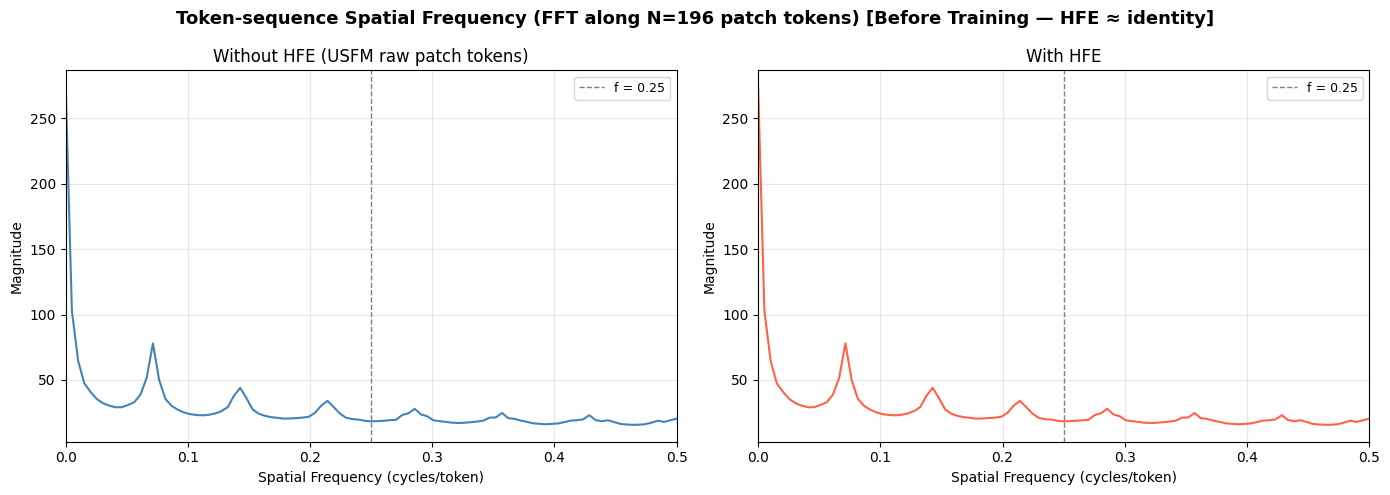


📊 High-frequency energy ratio (f >= 0.25):
   Without HFE : 0.3364
   With HFE    : 0.3364
   Δ           : -0.0000


In [10]:
# ── FFT 可视化：训练前
# alpha=0 → gate=tanh(0)=0 → HFE 此时是 identity，预期 Δ ≈ 0
visualize_hfe_fft(
    model          = model,
    dataloader     = val_loader,
    device         = device,
    num_batches    = 5,
    save_path      = OUTPUT_PATH / 'fft_before_training.png',
    title_suffix   = ' [Before Training — HFE ≈ identity]'
)

In [11]:
def train_epoch(model, dataloader, criterion, optimizer, device):
    model.train()
    total_loss = 0
    correct = 0
    total = 0
    
    for batch in tqdm(dataloader, desc='Training', leave=False):
        images = batch['image'].to(device)
        labels = batch['organ_label'].to(device)
        
        optimizer.zero_grad()
        outputs = model(images)
        loss = criterion(outputs, labels)
        loss.backward()
        torch.nn.utils.clip_grad_norm_(model.parameters(), max_norm=1.0)
        optimizer.step()
        
        total_loss += loss.item()
        _, predicted = torch.max(outputs.data, 1)
        total   += labels.size(0)
        correct += (predicted == labels).sum().item()
    
    return total_loss / len(dataloader), correct / total


def validate(model, dataloader, criterion, device):
    model.eval()
    total_loss = 0
    correct = 0
    total = 0
    
    with torch.no_grad():
        for batch in tqdm(dataloader, desc='Validating', leave=False):
            images = batch['image'].to(device)
            labels = batch['organ_label'].to(device)
            outputs = model(images)
            loss = criterion(outputs, labels)
            total_loss += loss.item()
            _, predicted = torch.max(outputs.data, 1)
            total   += labels.size(0)
            correct += (predicted == labels).sum().item()
    
    return total_loss / len(dataloader), correct / total


print('✓ Training functions ready')

✓ Training functions ready


In [12]:
print('\nStarting training...\n')
train_losses = []
train_accs   = []
val_losses   = []
val_accs     = []

best_val_acc     = 0
best_model_path  = OUTPUT_PATH / 'best_model.pth'
patience         = 15
patience_counter = 0

for epoch in range(CONFIG['num_epochs']):
    print(f'Epoch [{epoch+1}/{CONFIG["num_epochs"]}]', end=' | ')
    
    train_loss, train_acc = train_epoch(model, train_loader, criterion, optimizer, device)
    val_loss,   val_acc   = validate(model, val_loader, criterion, device)
    scheduler.step()
    
    train_losses.append(train_loss)
    train_accs.append(train_acc)
    val_losses.append(val_loss)
    val_accs.append(val_acc)
    
    print(f'Train: {train_loss:.4f}/{train_acc:.4f} | Val: {val_loss:.4f}/{val_acc:.4f}', end='')
    
    if val_acc > best_val_acc:
        best_val_acc     = val_acc
        patience_counter = 0
        model_to_save = model.module if isinstance(model, nn.DataParallel) else model
        torch.save({
            'epoch': epoch,
            'model_state_dict': model_to_save.state_dict(),
            'val_acc': val_acc,
        }, best_model_path)
        print(' ✓')
    else:
        patience_counter += 1
        print()
        if patience_counter >= patience:
            print(f'Early stopping at epoch {epoch}')
            break

print(f'\nTraining done. Best Val Acc: {best_val_acc:.4f}')


Starting training...

Epoch [1/50] | 

Train: 1.2167/0.4736 | Val: 0.6882/0.7323 ✓
Epoch [2/50] | 

Train: 0.4621/0.7858 | Val: 0.2209/0.8710 ✓
Epoch [3/50] | 

Train: 0.2229/0.8892 | Val: 0.1643/0.9226 ✓
Epoch [4/50] | 

Train: 0.1519/0.9392 | Val: 0.1785/0.9000
Epoch [5/50] | 

...

Train: 0.0065/0.9986 | Val: 0.1195/0.9742
Epoch [24/50] | 

Train: 0.0113/0.9959 | Val: 0.1356/0.9742
Epoch [25/50] | 

Train: 0.0079/0.9986 | Val: 0.0694/0.9839
Epoch [26/50] | 

Train: 0.0136/0.9959 | Val: 0.0852/0.9806
Epoch [27/50] | 

Train: 0.0113/0.9959 | Val: 0.0691/0.9839
Early stopping at epoch 26

Training done. Best Val Acc: 0.9871


/tmp/tmp.jHCsopZqRh/ipykernel_3045928/2774840010.py:1: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  checkpoint = torch.load(best_model_path, map_location=device)



📊 Test Results:
✓ Test Loss:     0.0784
✓ Test Accuracy: 0.9742


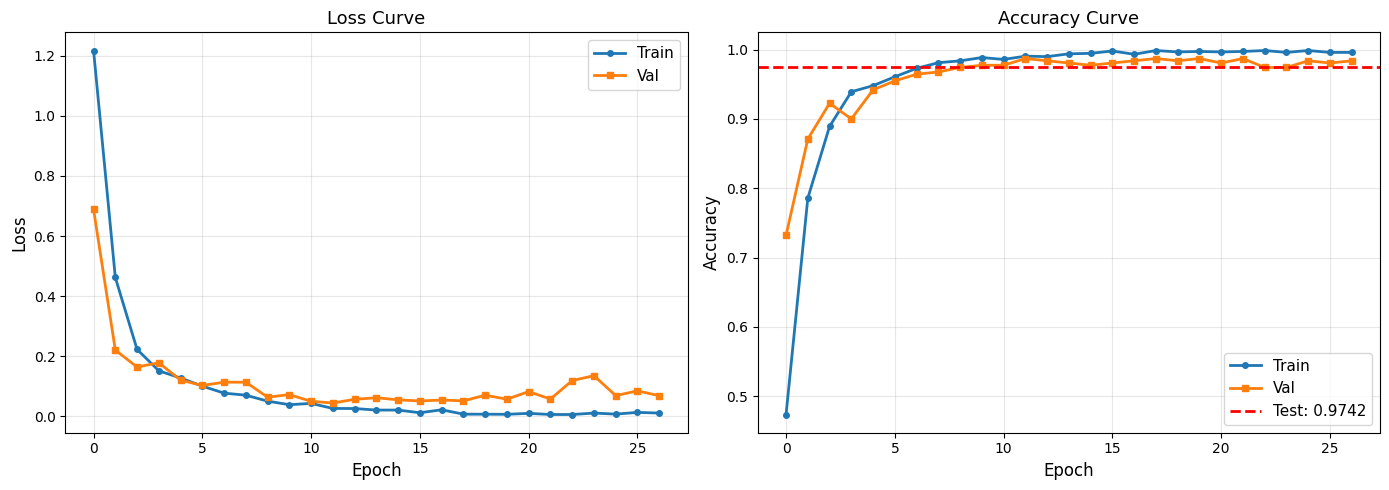

✓ Saved curves to /gpfs/gibbs/project/papademetris/jg3279/USFM/week9/ablation_C_hfe_nogate/curves.png


In [13]:
checkpoint = torch.load(best_model_path, map_location=device)
model_to_load = model.module if isinstance(model, nn.DataParallel) else model
model_to_load.load_state_dict(checkpoint['model_state_dict'])

test_loss, test_acc = validate(model, test_loader, criterion, device)
print(f'\n📊 Test Results:')
print(f'✓ Test Loss:     {test_loss:.4f}')
print(f'✓ Test Accuracy: {test_acc:.4f}')

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

axes[0].plot(train_losses, label='Train', marker='o', markersize=4, linewidth=2)
axes[0].plot(val_losses,   label='Val',   marker='s', markersize=4, linewidth=2)
axes[0].set_ylabel('Loss', fontsize=12)
axes[0].set_xlabel('Epoch', fontsize=12)
axes[0].legend(fontsize=11)
axes[0].grid(True, alpha=0.3)
axes[0].set_title('Loss Curve', fontsize=13)

axes[1].plot(train_accs, label='Train', marker='o', markersize=4, linewidth=2)
axes[1].plot(val_accs,   label='Val',   marker='s', markersize=4, linewidth=2)
axes[1].axhline(y=test_acc, color='r', linestyle='--', label=f'Test: {test_acc:.4f}', linewidth=2)
axes[1].set_ylabel('Accuracy', fontsize=12)
axes[1].set_xlabel('Epoch', fontsize=12)
axes[1].legend(fontsize=11)
axes[1].grid(True, alpha=0.3)
axes[1].set_title('Accuracy Curve', fontsize=13)

plt.tight_layout()
plt.savefig(OUTPUT_PATH / 'curves.png', dpi=300, bbox_inches='tight')
plt.show()
print(f'✓ Saved curves to {OUTPUT_PATH / "curves.png"}')

✓ FFT plot saved → /gpfs/gibbs/project/papademetris/jg3279/USFM/week9/ablation_C_hfe_nogate/fft_after_training.png


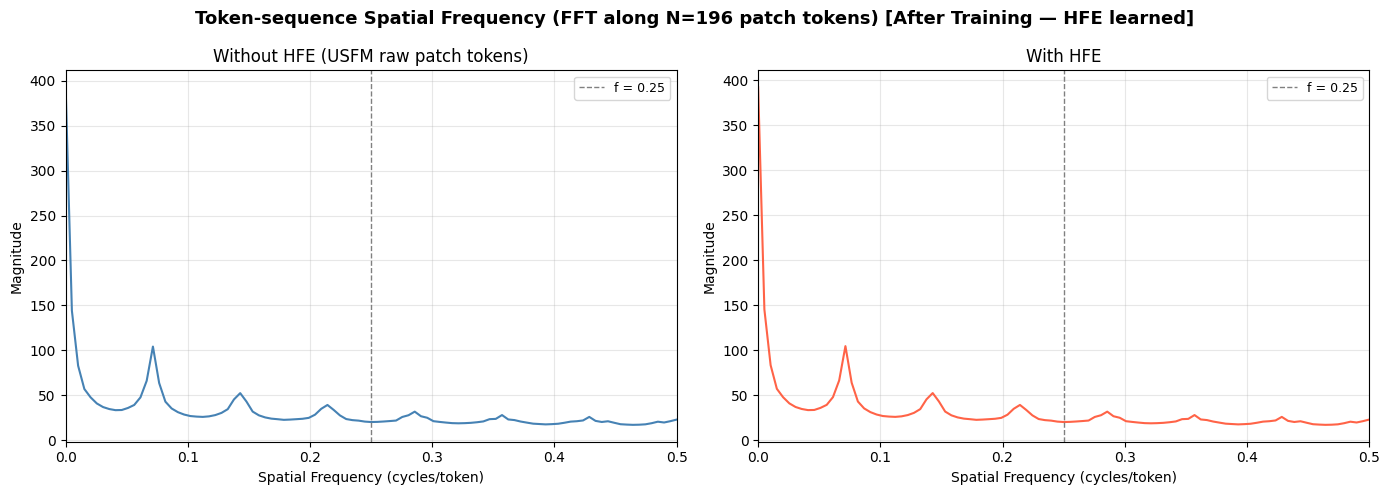


📊 High-frequency energy ratio (f >= 0.25):
   Without HFE : 0.3127
   With HFE    : 0.3123
   Δ           : -0.0004


In [14]:
# ── FFT 可视化：训练后
# alpha 已学习 → gate = tanh(alpha) > 0 → HFE 真正开始增强高频
# 对比训练前 Δ≈0，训练后 Δ>0 才能说明是学出来的高频增强
visualize_hfe_fft(
    model          = model,
    dataloader     = val_loader,
    device         = device,
    num_batches    = 5,
    save_path      = OUTPUT_PATH / 'fft_after_training.png',
    title_suffix   = ' [After Training — HFE learned]'
)

Running CLS attention map visualization...
✓ Attention map saved → /gpfs/gibbs/project/papademetris/jg3279/USFM/week9/ablation_C_hfe_nogate/cls_attention_map.png


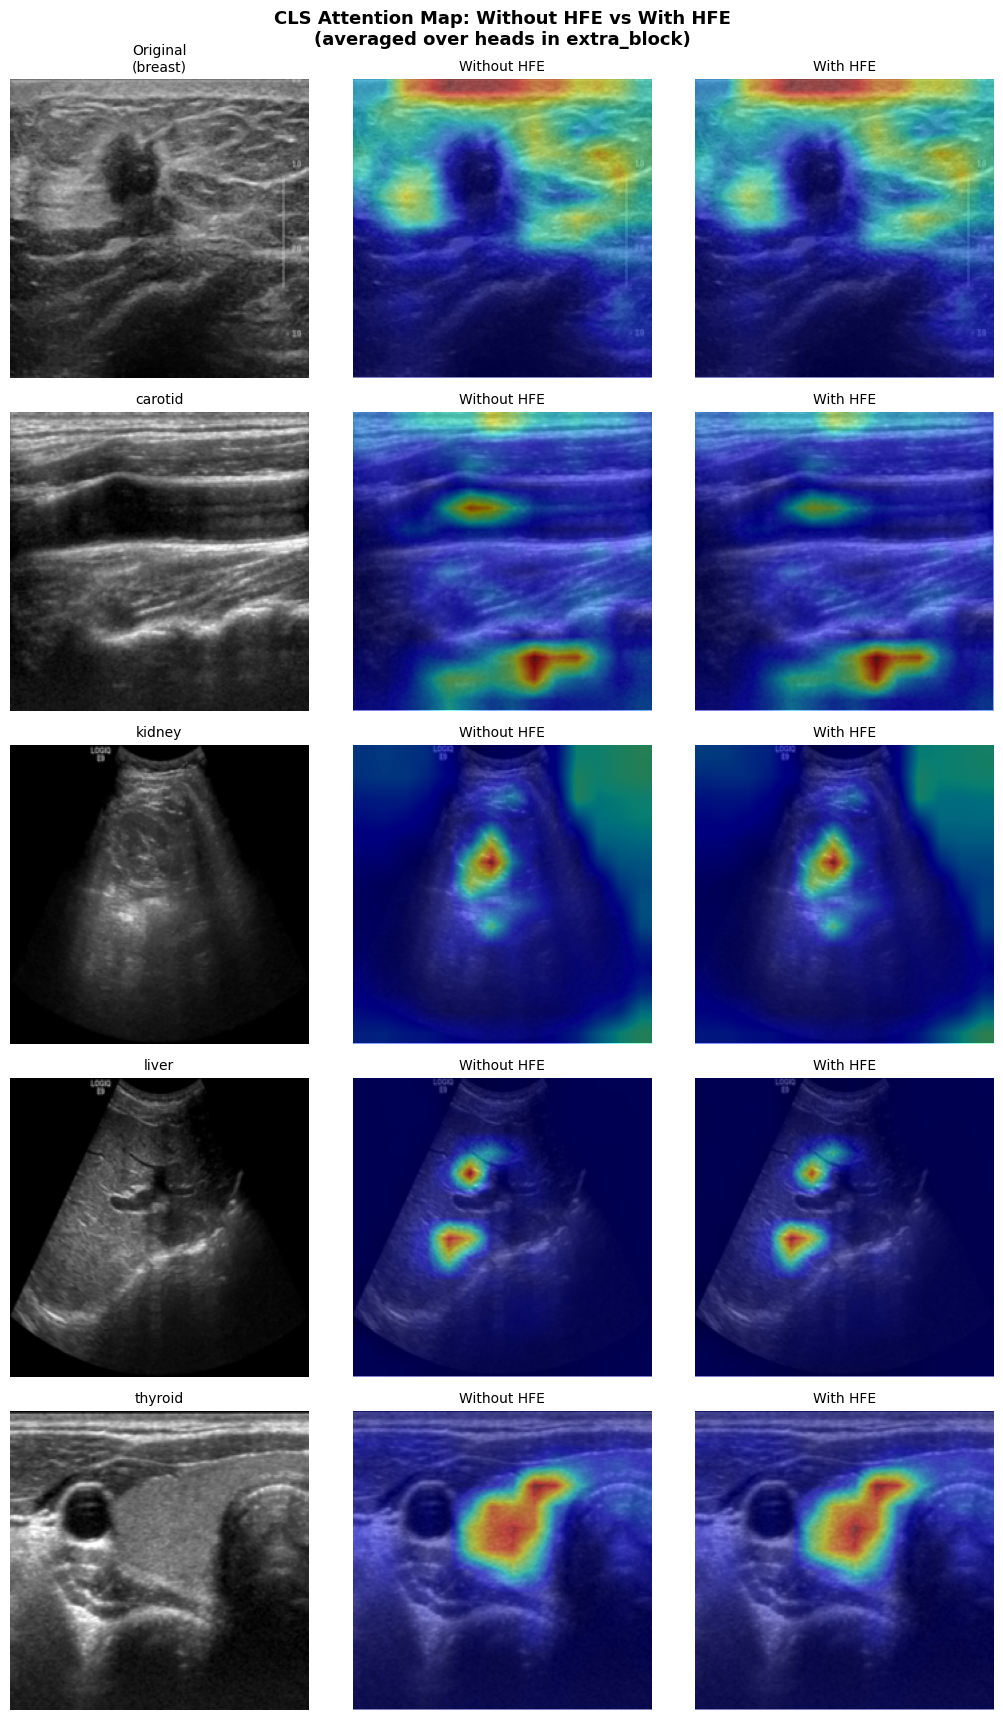

✓ CLS attention map done


In [15]:
# ─────────────────────────────────────────────────────────────────
# CLS Attention Map: Without HFE vs With HFE
# 每个 organ 各取1张样本，对比 extra_block 里 CLS 的 attention 分布
# 如果 HFE 有效：With HFE 应 attend 到更细粒度/边缘的区域
# ─────────────────────────────────────────────────────────────────

def get_cls_attention_map(model, image_tensor, device, use_hfe=True):
    """
    Extract CLS→patch attention from extra_block via attn_drop forward hook.

    Args:
        image_tensor: [1, 3, 224, 224]
        use_hfe: if True, pass through HFE before extra_block
    Returns:
        attn_map: [14, 14] averaged over heads
    """
    model.eval()
    actual_model = model.module if isinstance(model, nn.DataParallel) else model
    backbone_model = actual_model.backbone

    captured = {}
    attn_module = actual_model.extra_block.attn
    orig_fused_attn = getattr(attn_module, 'fused_attn', None)

    def hook_fn(module, input, output):
        # input[0]: [B, H, N, N] softmax attention before dropout
        captured['attn'] = input[0].detach()

    if orig_fused_attn is not None:
        attn_module.fused_attn = False
    handle = attn_module.attn_drop.register_forward_hook(hook_fn)

    try:
        with torch.no_grad():
            image_tensor = image_tensor.to(device)
            features = backbone_model.forward_features(image_tensor)  # [1,197,768]
            tokens = actual_model.hfe(features) if use_hfe else features
            _ = actual_model.extra_block(tokens)
    finally:
        handle.remove()
        if orig_fused_attn is not None:
            attn_module.fused_attn = orig_fused_attn

    if 'attn' not in captured:
        raise RuntimeError('Failed to capture attention weights from extra_block.attn.attn_drop')

    # captured['attn']: [1, H, 197, 197]
    # CLS (row 0) → patch tokens (cols 1:)
    attn = captured['attn'][0]           # [H, 197, 197]
    cls_attn = attn[:, 0, 1:]            # [H, 196]
    cls_attn = cls_attn.mean(dim=0)      # [196] average over heads
    cls_attn = cls_attn.cpu().numpy().reshape(14, 14)
    cls_attn = (cls_attn - cls_attn.min()) / (cls_attn.max() - cls_attn.min() + 1e-8)
    return cls_attn


def denormalize(tensor):
    """Reverse ImageNet normalization for display."""
    mean = torch.tensor([0.485, 0.456, 0.406]).view(3,1,1)
    std  = torch.tensor([0.229, 0.224, 0.225]).view(3,1,1)
    return (tensor.cpu() * std + mean).clamp(0,1).permute(1,2,0).numpy()


def visualize_cls_attention(model, dataset, device,
                             save_path=None, num_per_organ=1):
    """
    For each organ, pick num_per_organ samples and plot:
      Col 0: original image
      Col 1: CLS attention WITHOUT HFE
      Col 2: CLS attention WITH HFE
    """
    organs      = CONFIG['organ_classes']
    n_organs    = len(organs)
    cols_per    = 3  # image | no-hfe | with-hfe

    fig, axes = plt.subplots(
        n_organs * num_per_organ, cols_per,
        figsize=(cols_per * 3.5, n_organs * num_per_organ * 3.5)
    )
    fig.suptitle('CLS Attention Map: Without HFE vs With HFE\n(averaged over heads in extra_block)',
                 fontsize=13, fontweight='bold')
    axes = np.array(axes)
    if axes.ndim == 1:
        axes = axes.reshape(1, -1)

    # index samples by organ
    organ_samples = {o: [] for o in organs}
    for idx, s in enumerate(dataset.samples):
        if len(organ_samples[s['organ']]) < num_per_organ:
            organ_samples[s['organ']].append(idx)
        if all(len(v) >= num_per_organ for v in organ_samples.values()):
            break

    row = 0
    for organ in organs:
        for idx in organ_samples[organ]:
            sample = dataset[idx]
            img_tensor = sample['image'].unsqueeze(0)  # [1,3,224,224]

            attn_nohfe = get_cls_attention_map(model, img_tensor, device, use_hfe=False)
            attn_withhfe = get_cls_attention_map(model, img_tensor, device, use_hfe=True)
            img_display = denormalize(sample['image'])

            ax_img, ax_no, ax_yes = axes[row]

            # Original image
            ax_img.imshow(img_display)
            ax_img.set_title(f'{organ}', fontsize=10)
            ax_img.axis('off')

            # Without HFE
            ax_no.imshow(img_display)
            ax_no.imshow(attn_nohfe, cmap='jet', alpha=0.5,
                         extent=[0,224,224,0], interpolation='bilinear')
            ax_no.set_title('Without HFE', fontsize=10)
            ax_no.axis('off')

            # With HFE
            ax_yes.imshow(img_display)
            ax_yes.imshow(attn_withhfe, cmap='jet', alpha=0.5,
                          extent=[0,224,224,0], interpolation='bilinear')
            ax_yes.set_title('With HFE', fontsize=10)
            ax_yes.axis('off')

            if row == 0:
                ax_img.set_title(f'Original\n({organ})', fontsize=10)
                ax_no.set_title('Without HFE', fontsize=10)
                ax_yes.set_title('With HFE', fontsize=10)

            row += 1

    plt.tight_layout()
    if save_path:
        plt.savefig(save_path, dpi=150, bbox_inches='tight')
        print(f'✓ Attention map saved → {save_path}')
    plt.show()
    plt.close()


print('Running CLS attention map visualization...')
visualize_cls_attention(
    model       = model,
    dataset     = val_dataset,
    device      = device,
    save_path   = OUTPUT_PATH / 'cls_attention_map.png',
    num_per_organ = 1
)
print('✓ CLS attention map done')

In [16]:
def extract_embeddings(model, dataloader, device):
    model.eval()
    actual_model = model.module if isinstance(model, nn.DataParallel) else model
    embeddings_list = []
    organs_list     = []
    
    with torch.no_grad():
        for batch in tqdm(dataloader, desc='Extracting', leave=False):
            images     = batch['image'].to(device)
            embeddings = actual_model.extract_features(images)
            embeddings_list.append(embeddings.cpu().numpy())
            organs_list.extend(batch['organ_name'])
    
    return np.vstack(embeddings_list), np.array(organs_list)


print('Extracting embeddings...')
for split_name, loader in [('train', train_loader), ('val', val_loader), ('test', test_loader)]:
    embeddings, organs = extract_embeddings(model, loader, device)
    np.save(OUTPUT_PATH / f'embeddings_{split_name}.npy', embeddings)
    np.save(OUTPUT_PATH / f'organs_{split_name}.npy',     organs)
    print(f'✓ {split_name}: {embeddings.shape}')

print(f'\n✅ Done!')
print(f'Results saved to: {OUTPUT_PATH}')

actual = model.module if isinstance(model, nn.DataParallel) else model
print(f'Final strength_scale: {actual.hfe.strength_scale.item():.4f}')


Extracting embeddings...


✓ train: (1480, 768)


✓ val: (310, 768)


✓ test: (310, 768)

✅ Done!
Results saved to: /gpfs/gibbs/project/papademetris/jg3279/USFM/week9/ablation_C_hfe_nogate
Final strength_scale: 0.1229
